In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from core.data import load_from_kaggle


c:\Users\yamen\Desktop\Weiterbildung\visual Studio Code\mein-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
dataset_link = "mohankrishnathalla/diabetes-health-indicators-dataset" # replace with your dataset link from Kaggle 
destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    )

100%|██████████| 3.75M/3.75M [00:00<00:00, 4.70MB/s]

Extracting files...


Loading dataset from C:\Users\yamen\.cache\kagglehub\datasets\mohankrishnathalla\diabetes-health-indicators-dataset\versions\1 to ../data/raw\diabetes-health-indicators-dataset
Moving file: C:\Users\yamen\.cache\kagglehub\datasets\mohankrishnathalla\diabetes-health-indicators-dataset\versions\1\diabetes_dataset.csv to c:\Users\yamen\Desktop\Weiterbildung\visual Studio Code\mein-project\notebooks\../data/raw\diabetes-health-indicators-dataset
Files moved to '../data/raw\diabetes-health-indicators-dataset' directory.


In [5]:
files

['diabetes_dataset.csv']

In [6]:
df = pd.read_csv("/".join(["../data/raw/", dataset_name, files[0]]))
df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [7]:
display(
    "Shape",
    df.shape,
    "Description",
    df.describe().round(2).T,
    "Duplicates",
    df.duplicated().sum(),
)


pd.DataFrame(
    {
        "Data Types": df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Unique Values": df.nunique(),
        "Sample Values": [df[col].sample(3).tolist() for col in df.columns]
    })


'Shape'

(100000, 31)

'Description'

,count,mean,std,min,25%,50%,75%,max
age,100000.0,50.12,15.60,18.00,39.00,50.00,61.00,90.00
alcohol_consumption_per_week,100000.0,2.00,1.42,0.00,1.00,2.00,3.00,10.00
physical_activity_minutes_per_week,100000.0,118.91,84.41,0.00,57.00,100.00,160.00,833.00
diet_score,100000.0,5.99,1.78,0.00,4.80,6.00,7.20,10.00
sleep_hours_per_day,100000.0,7.00,1.09,3.00,6.30,7.00,7.70,10.00
screen_time_hours_per_day,100000.0,6.00,2.47,0.50,4.30,6.00,7.70,16.80
family_history_diabetes,100000.0,0.22,0.41,0.00,0.00,0.00,0.00,1.00
hypertension_history,100000.0,0.25,0.43,0.00,0.00,0.00,1.00,1.00
cardiovascular_history,100000.0,0.08,0.27,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,25.61,3.59,15.00,23.20,25.60,28.00,39.20


'Duplicates'

np.int64(0)

,Data Types,Missing Values,Unique Values,Sample Values
age,int64,0,73,"[41, 48, 60]"
gender,object,0,3,"[Male, Male, Male]"
ethnicity,object,0,5,"[Black, White, White]"
education_level,object,0,4,"[Graduate, Graduate, Highschool]"
income_level,object,0,5,"[Lower-Middle, Middle, Lower-Middle]"
employment_status,object,0,4,"[Retired, Employed, Employed]"
smoking_status,object,0,3,"[Never, Current, Current]"
alcohol_consumption_per_week,int64,0,11,"[0, 2, 2]"
physical_activity_minutes_per_week,int64,0,620,"[78, 82, 55]"
diet_score,float64,0,101,"[6.4, 7.5, 5.4]"


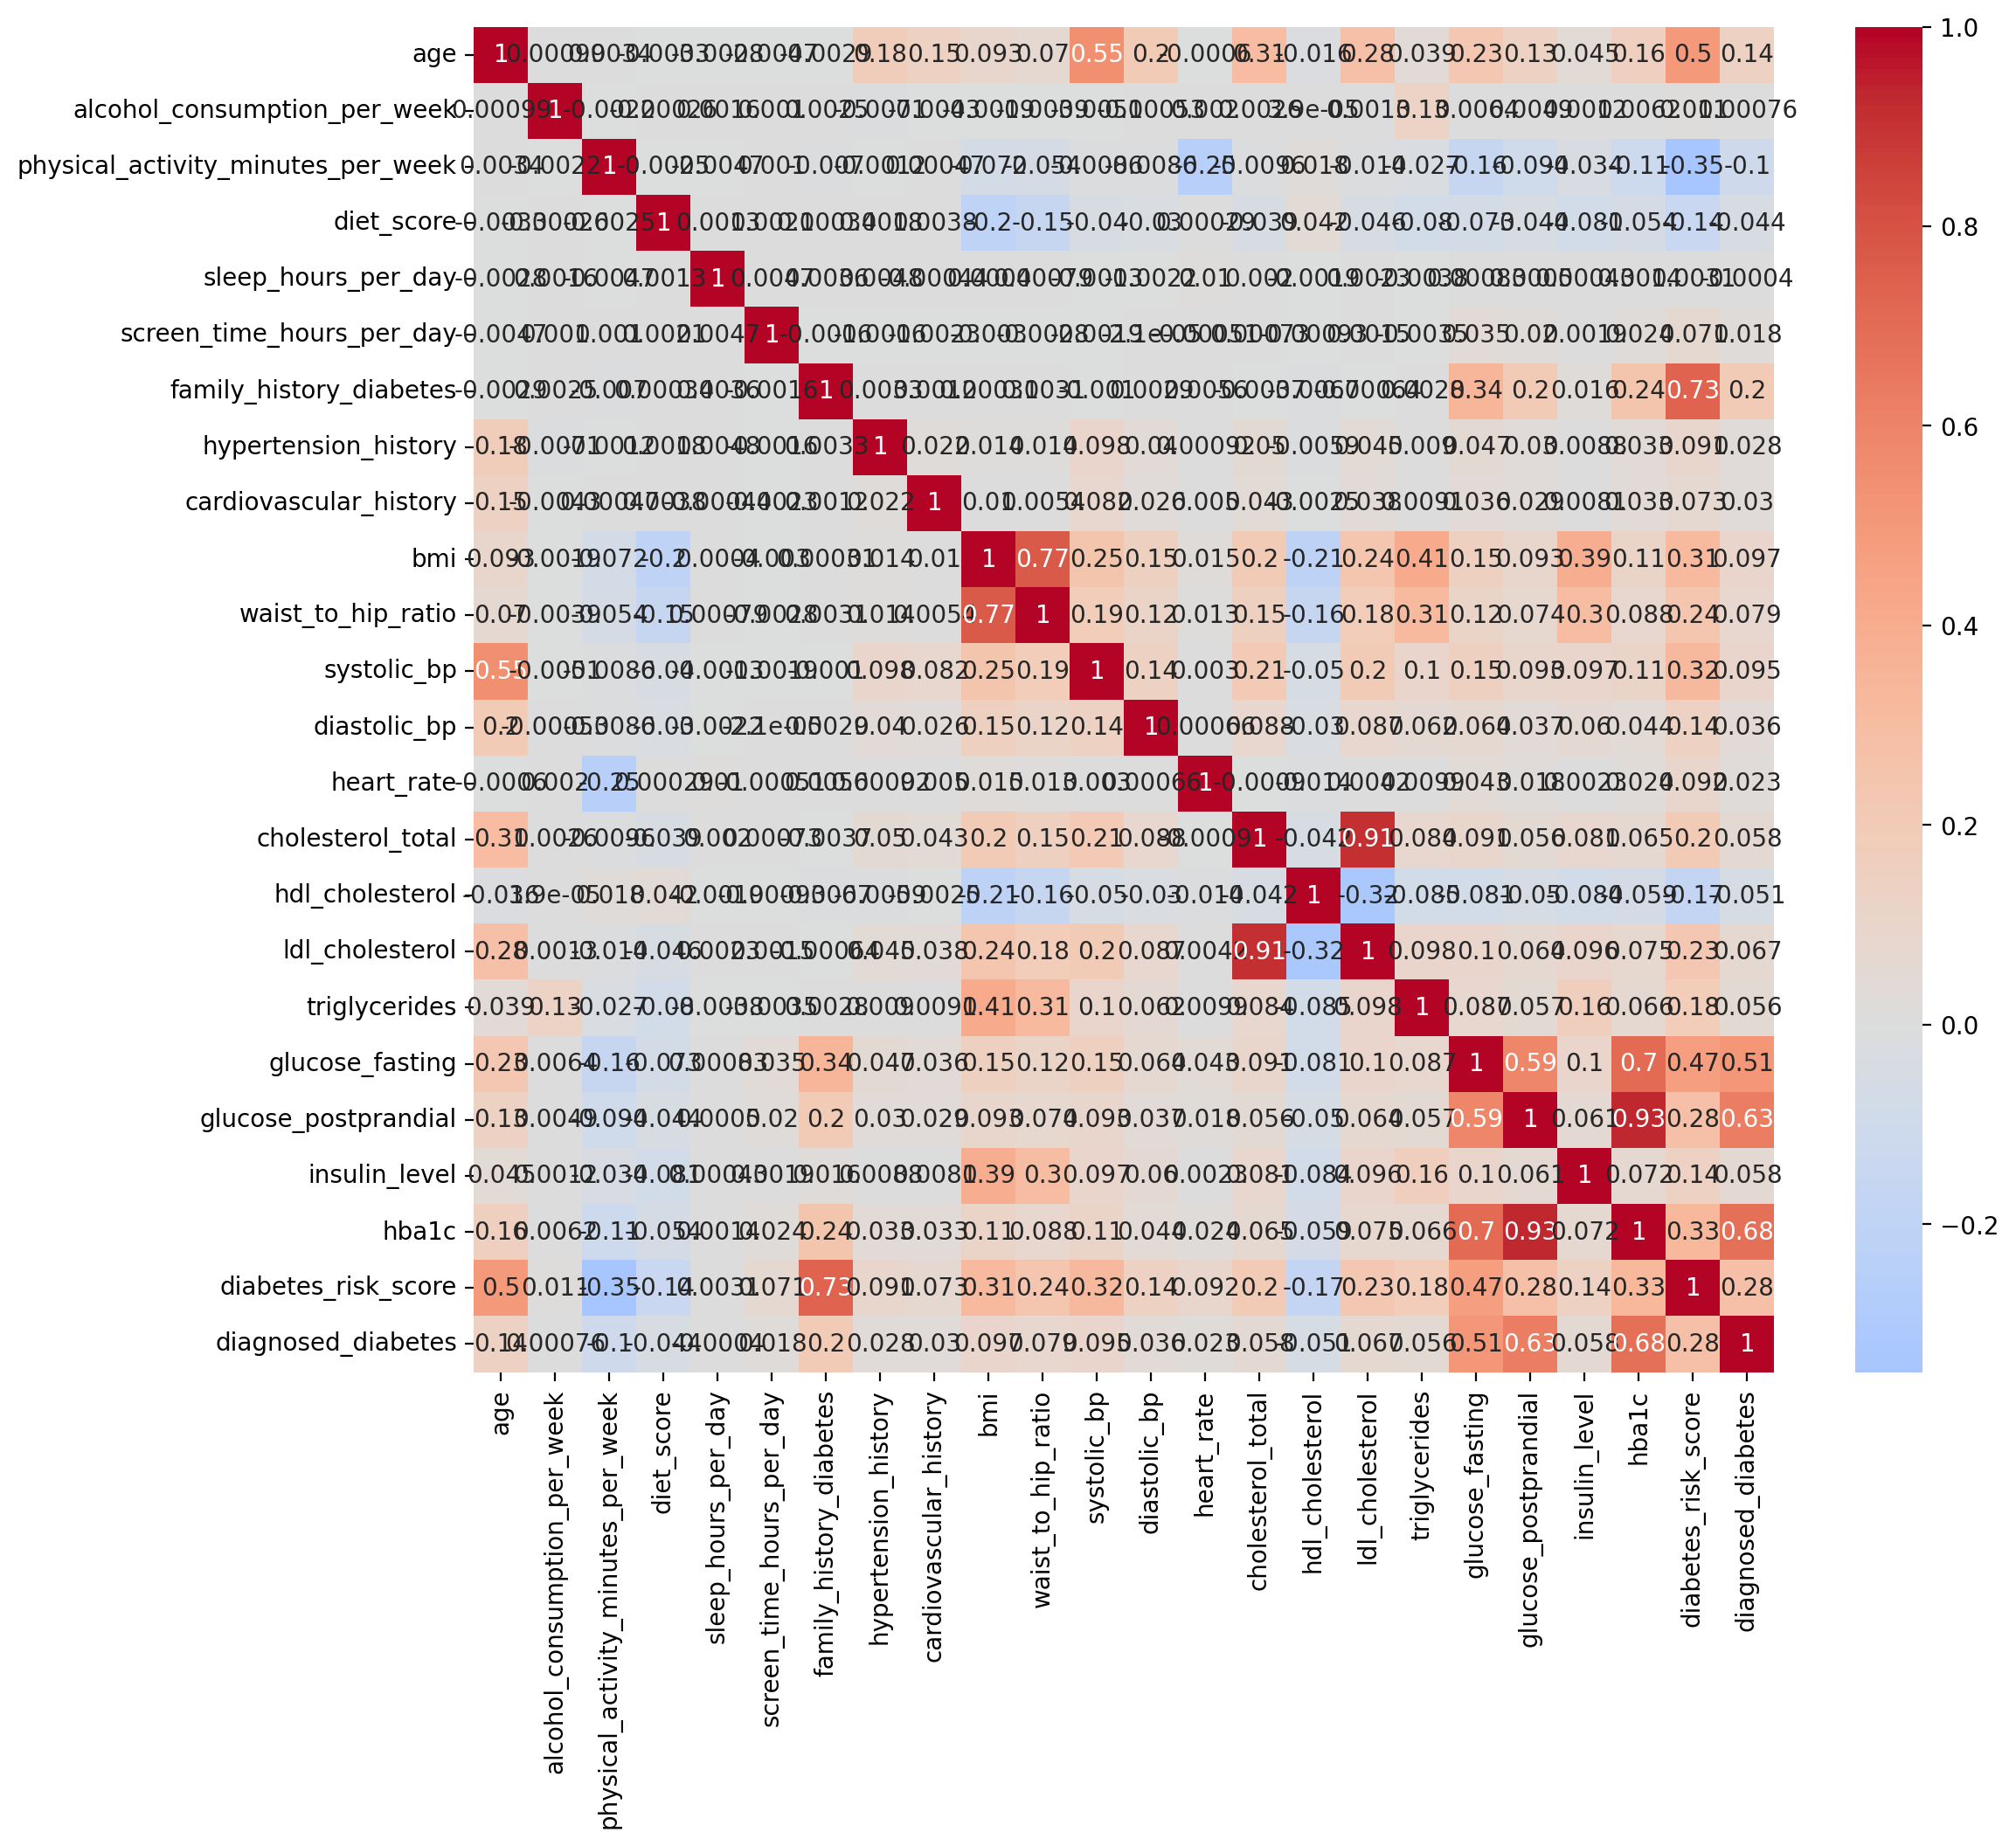

In [8]:
fig, ax = plt.subplots(figsize=(12, 10), dpi=200)

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", center=0, ax=ax);